# Dataset

In [8]:
import pandas as pd
import numpy as np

# Vamos a cargar el dataset de vino de sklearn y mostrar algunos datos
# Importamos load_wine de sklearn.datasets
from sklearn.datasets import load_wine
data = load_wine()
data.target[[10, 80, 140]]
# Mostramos los nombres de las clases del dataset
list(data.target_names)

# Convertimos los datos a un DataFrame de pandas
df = pd.DataFrame(data.data, columns=data.feature_names)


# Regresión lineal simple

In [9]:
# Calcularemos la regresión lineal simple entre dos variables del dataset de vino
# Para esto, definimos una función que calcula la regresión lineal simple
def regresion_lineal_simple(x, y, num_iteraciones=1000, eta=0.01):
    n = len(x)
    w = 0
    b = 0

    for _ in range(num_iteraciones):
        # Definición de la predicción
        y_pred = w * x + b
        # Ahora calculamos el error
        error = y_pred - y
        
        # Calculo de la derivada
        dw = (2 / n) * np.sum(error * x)
        db = (2 / n) * np.sum(error)
        
        # Actualizamos de parámetros
        w -= eta * dw
        b -= eta * db
    return w, b

c:\Users\Majo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Majo\AppData\Local\Temp\ipykernel_16700\2249188864.py:19: RuntimeWarning: invalid value encountered in scalar subtract
  w -= eta * dw


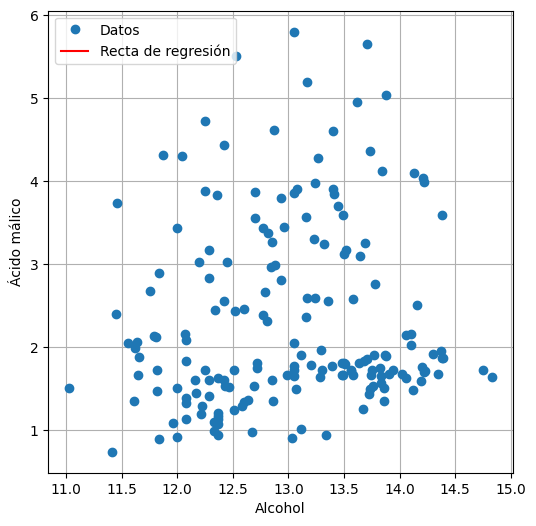

Pendiente (w): nan, Intersección (b): nan


In [11]:
import matplotlib.pyplot as plt
# Regresión lineal entre 'alcohol' y 'malic_acid' 
x = df["alcohol"].values
y = df["malic_acid"].values

w, b = regresion_lineal_simple(x, y)

y_pred = w * x + b

plt.figure(figsize=(6, 6))
plt.plot(x, y, 'o', label='Datos')
x_linea = np.linspace(min(x), max(x), 100)
y_linea = w * x_linea + b
plt.plot(x_linea, y_linea, 'r-', label='Recta de regresión')
plt.grid(True)
plt.xlabel("Alcohol")
plt.ylabel("Ácido málico")
plt.legend()
plt.show()

print(f"Pendiente (w): {w:.4f}, Intersección (b): {b:.4f}")

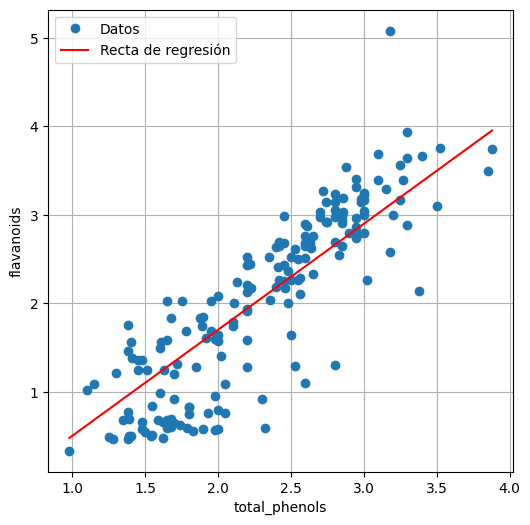

Pendiente (w): 1.1964, Intersección (b): -0.6901


In [12]:
# Regresión lineal entre 'total_phenols' y 'flavanoids' (relación fuerte)
x = df["total_phenols"].values
y = df["flavanoids"].values

w, b = regresion_lineal_simple(x, y)

plt.figure(figsize=(6, 6))
plt.plot(x, y, 'o', label='Datos')
x_linea = np.linspace(min(x), max(x), 100)
y_linea = w * x_linea + b
plt.plot(x_linea, y_linea, 'r-', label='Recta de regresión')
plt.grid(True)
plt.xlabel("total_phenols")
plt.ylabel("flavanoids")
plt.legend()
plt.show()

print(f"Pendiente (w): {w:.4f}, Intersección (b): {b:.4f}")

# Regresión lineal múltiple

In [13]:
# Definimos una función que calcula la regresión lineal múltiple
    # X va a ser una matriz mxn 
    # y va a ser un vector 1xn
    # w_0 va a ser un escalar
    # w_j va a ser un vector 1xn
    # n va a ser el número de observaciones
    # m va a ser el número de dimensiones

def regresion_lineal_multiple(X, y, num_iteraciones=1000, eta=0.01):
    n, m = X.shape
    w = np.zeros(m)
    w_0 = 0

    for _ in range(num_iteraciones):
        # Definición de la predicción
        # .dot es el producto entre una matriz y un vector
        y_pred = np.dot(X, w) + w_0

        # Ahora calculamos el error
        error = y_pred - y
        
        # Calculo de la derivada
        dw = (2 / n) * np.dot(X.T, error)
        dw_0 = (2 / n) * np.sum(error)
        
        # Actualizamos de parámetros
        w -= eta * dw
        w_0 -= eta * dw_0
    return w, w_0

In [14]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 100

# Variables independientes
x1 = np.random.uniform(0, 10, n)
x2 = np.random.uniform(0, 5, n)
w_true = np.array([2.0, -3.5])
b_true = 4.0

# Variable dependiente
t = w_true[0] * x1 + w_true[1] * x2 + b_true + np.random.normal(0, 1.0, n)
X = np.column_stack((x1, x2))

In [15]:
w, w_0 = regresion_lineal_multiple(X, t)

In [16]:
import plotly.graph_objects as go
import numpy as np

def graficar_regresion_3d(X, t, w, b, title="Regresión Lineal Múltiple (3D)"):

    """
        Grafica los datos en 3D junto con el plano ajustado por regresión lineal múltiple.
        Parámetros:
        - X: matriz (n_samples x 2) de variables independientes
        - t: vector (n_samples,) de valores reales
        - w: vector (2,) de pesos aprendidos
        - b: sesgo aprendido
        - title: título del gráfico
    """

    assert X.shape[1] == 2, "La función solo admite datos con exactamente 2 variables independientes."

    # Crear malla para la superficie de predicción
    x_surf, y_surf = np.meshgrid(
        np.linspace(X[:, 0].min(), X[:, 0].max(), 50),
        np.linspace(X[:, 1].min(), X[:, 1].max(), 50)
    )

    # Predecir valores z para la superficie
    z_surf = (w[0] * x_surf + w[1] * y_surf + b)

    # Crear gráfico
    fig = go.Figure(data=[
        go.Scatter3d(x=X[:, 0], y=X[:, 1], z=t,
                        mode='markers',
                        marker=dict(size=5, opacity=0.8),
                        name='Datos reales'),
        go.Surface(x=x_surf, y=y_surf, z=z_surf,
                    opacity=0.5,
                    colorscale='Viridis',
                    name='Plano de regresión')
    ])
    fig.update_layout(title=title,
                        scene=dict(
                            xaxis_title='X1',
                            yaxis_title='X2',
                            zaxis_title='Y'),
                        margin=dict(l=0, r=0, b=0, t=40))
    fig.show()

In [17]:
graficar_regresion_3d(X, t, w, w_0)

In [19]:
# R2 = 1 - (variancia del error / varianza total) = 1 - (SEE - STT)
# Si R2 es 0, significa que el modelo no explica nada de la variabilidad de los datos.
# Si R2 es 1, significa que el modelo explica toda la variabilidad de los datos.

# Definimos una función para calcular el coeficiente de determinación R^2
# Los parámetros son: valores reales y valores predichos
def r2_score(y_true, y_pred):
    varianza_error = np.sum((y_true - y_pred) ** 2)
    varianza_total = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (varianza_error / varianza_total)

# Calculamos el R^2 para nuestro modelo
r2 = r2_score(t, np.dot(X, w) + w_0)
# Armamos el boolean para ver si el modelo es bueno
if r2 > 0.8:
    print("El modelo es bueno")
else:
    print("El modelo no es bueno")
print(f"Coeficiente de determinación R^2: {r2:.4f}")

El modelo es bueno
Coeficiente de determinación R^2: 0.9843
